# EPL448 – Deliverable 3: Predictive Model Development & Performance Evaluation
## CERN Electron Collision Dataset – Team 2
**Members:** Varnavas Tryfonos, Thrasos Sazeidis, Andreas Evagorou  
**Dataset:** [CERN Electron Collision Data (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/cern-electron-collision-data)

---
## 0. Setup & Imports

In [ ]:
import sys
import os
from pathlib import Path

# Allow notebooks/ to import from src/
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split, cross_validate, KFold, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning, module='sklearn')
warnings.filterwarnings('ignore', message='.*max_iter.*')

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed - install with: pip install xgboost')

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not installed - install with: pip install catboost')

from src.features import LOG_FEATURES, add_engineered_features, build_v1, build_v2, build_v3, build_v4
from src.evaluation import compute_metrics, CV_SCORING
from src.models import N_TOP_MODELS, N_TOP_DATASETS, RANDOM_STATE
from src.validation import validate_raw, validate_clean

MODEL_NAMES = ('KNN', 'CAT', 'ET', 'XGB')

PARAM_GRIDS = {
    'KNN': {
        'model__n_neighbors': [3, 5, 10, 15, 20],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    'CAT': {
        'model__depth': [6, 8],
        'model__learning_rate': [0.03, 0.1],
        'model__n_estimators': [300, 500],
        'model__l2_leaf_reg': [3, 5],
    },
    'ET': {
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'XGB': {
        'model__n_estimators': [100, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 6, 10],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
    },
}

def build_pipeline(model_name: str, use_pca: bool = False) -> Pipeline:
    steps = []
    if model_name in ('KNN',) or use_pca:
        steps.append(('scaler', StandardScaler()))
    if use_pca:
        steps.append(('pca', PCA(n_components=0.95)))

    if model_name == 'KNN':
        steps.append(('model', KNeighborsRegressor(n_jobs=1)))
    elif model_name == 'CAT':
        if not CATBOOST_AVAILABLE:
            raise ImportError("model_name='CAT' requires the optional 'catboost' package.")
        steps.append(('model', CatBoostRegressor(
            random_seed=RANDOM_STATE,
            task_type='GPU',
            devices='0',
            verbose=0,
            allow_writing_files=False,
        )))
    elif model_name == 'ET':
        steps.append(('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1)))
    elif model_name == 'XGB':
        if not XGBOOST_AVAILABLE:
            raise ImportError("model_name='XGB' requires the optional 'xgboost' package.")
        steps.append(('model', xgb.XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
            tree_method='hist',
            device='cuda',
        )))
    else:
        raise ValueError(f'Unknown model name: {model_name!r}')

    return Pipeline(steps)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

OUTPUTS_DIR = Path('../outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

print('All imports successful.')


---
## 1. Load Dataset & Reproduce Preprocessing from Deliverable 2

In [2]:
DATA_PATH = Path('../data/dielectron.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}.\n"
        "Download dielectron.csv and place it in the data/ directory.\n"
        "See data/README.md for instructions."
    )

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()   # fix L1: trailing space in column names

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

validate_raw(df)
print('Raw data validation passed.')

df_clean = df.drop(columns=['Run', 'Event'], errors='ignore').copy()
df_clean = df_clean.dropna(subset=['M']).reset_index(drop=True)

validate_clean(df_clean)
print(f'Working dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print('Clean data validation passed.')


Dataset loaded: 100,000 rows x 19 columns
Columns: ['Run', 'Event', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']
Raw data validation passed.
Working dataset: 99,915 rows x 17 columns
Clean data validation passed.


### 1.1 Feature Engineering Functions (from Deliverable 2)

In [3]:
# Feature engineering is defined in src/features.py (imported above).
# Key fix: delta_phi uses vectorised np.minimum (no .apply/lambda loop).
print('Feature engineering module loaded from src/features.py')
print(f'LOG_FEATURES: {LOG_FEATURES}')


Feature engineering module loaded from src/features.py
LOG_FEATURES: ['E1', 'E2', 'pt1', 'pt2']


### 1.2 Revisions from Deliverable 2

**Key revisions based on feedback:**

1. **Scaling removed from tree-based models:** In Deliverable 2, all dataset versions used `StandardScaler`. The professor noted that tree-based models (ExtraTrees, XGBoost) are scale-invariant. Scaling is now a pipeline step applied only for KNN and SVR.

2. **Feature selection / dimensionality reduction applied:** The original dataset has 16 features after dropping identifiers, and V4 (with engineered features) had 22. Many of these are redundant:
   - `px1, py1` are redundant with `pt1, phi1` (different coordinate system for the same momentum)
   - `px2, py2` are redundant with `pt2, phi2`
   - `pz1, pz2` are captured by `E, eta` (pz = pt × sinh(eta))
   - `phi1, phi2` individually have near-zero correlation with M
   - `eta1, eta2` individually are captured by `delta_eta`
   - `Q1, Q2` are captured by `opposite_sign`
   - `log_pt1, log_pt2` correlate ~0.87 with `log_E1, log_E2` and are captured by `sum_pt`

   V4 is now trimmed to **8 features** based on domain knowledge and the feature importance analysis from Deliverable 2. This reduces training time dramatically (especially for SVR and KNN) while preserving all physically meaningful information.

3. **Pipeline-based preprocessing:** All preprocessing is inside scikit-learn Pipelines to prevent data leakage during cross-validation.

### 1.3 Build Dataset Versions

| Version | Features | # Features | Target | Purpose |
|---------|----------|-----------|--------|--------|
| V1 | Original (raw, all features) | 16 | M | Baseline – no transforms |
| V2 | Log-transformed energy/pt | 16 | M | Reduce skewness |
| V3 | Log-transformed energy/pt | 16 | log(M) | Log target for relative errors |
| V4 | **Reduced: 8 selected features** (engineered + log energy) | 8 | M | Domain-driven feature selection |
| V5 | PCA on V2 features (in pipeline) | ~10 | M | Dimensionality reduction via PCA/SVD |

In [4]:
# V4_SELECTED is defined in src/features.py
from src.features import V4_SELECTED

y     = df_clean['M'].values
y_log = np.log(y)

X_v1 = build_v1(df_clean)
X_v2 = build_v2(df_clean)
X_v3 = build_v3(df_clean)
X_v4 = build_v4(df_clean)   # 8-feature reduced set
X_v5 = build_v2(df_clean)   # same as V2; PCA applied inside pipeline

mass_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

datasets_raw = {}
for name, X_df, y_arr in [
    ('V1', X_v1, y),
    ('V2', X_v2, y),
    ('V3', X_v3, y_log),
    ('V4', X_v4, y),
    ('V5', X_v5, y),
]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_df.values, y_arr, test_size=0.2,
        random_state=RANDOM_STATE, stratify=mass_bins
    )
    datasets_raw[name] = {
        'X_train':       X_tr,
        'X_test':        X_te,
        'y_train':       y_tr,
        'y_test':        y_te,
        'feature_names': list(X_df.columns),
        'log_target':    (name == 'V3'),
        'pca':           (name == 'V5'),
    }
    print(f'{name}: train={X_tr.shape}, test={X_te.shape}, '
          f'log_target={name == "V3"}, pca={name == "V5"}')

print(f'\nFeature counts: V1={X_v1.shape[1]}, V2={X_v2.shape[1]}, '
      f'V3={X_v3.shape[1]}, V4={X_v4.shape[1]}, V5={X_v5.shape[1]}')
print(f'\nV4 selected features: {V4_SELECTED}')


V1: train=(79932, 16), test=(19983, 16), log_target=False, pca=False
V2: train=(79932, 16), test=(19983, 16), log_target=False, pca=False
V3: train=(79932, 16), test=(19983, 16), log_target=True, pca=False
V4: train=(79932, 8), test=(19983, 8), log_target=False, pca=False
V5: train=(79932, 16), test=(19983, 16), log_target=False, pca=True

Feature counts: V1=16, V2=16, V3=16, V4=8, V5=16

V4 selected features: ['sum_E', 'sum_pt', 'delta_R', 'delta_eta', 'delta_phi', 'opposite_sign', 'log_E1', 'log_E2']


## 2. Model Evaluation Metrics

Since this is a **regression** problem (predicting invariant mass M in GeV), we use the following metrics:

<table>
  <thead>
    <tr><th>Metric</th><th>Formula</th><th>Why we use it</th></tr>
  </thead>
  <tbody>
    <tr><td><strong>RMSE</strong></td><td>\(\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}\)</td><td>Penalises large errors more heavily. Same units as target (GeV).</td></tr>
    <tr><td><strong>MAE</strong></td><td>\(\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert\)</td><td>Robust to outliers. Typical prediction error in GeV.</td></tr>
    <tr><td><strong>R^2</strong></td><td>\(1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}\)</td><td>Proportion of variance explained. 1.0 = perfect.</td></tr>
    <tr><td><strong>MAPE</strong></td><td>\(\frac{100}{n}\sum \left|\frac{y_i - \hat{y}_i}{y_i}\right|\)</td><td>Relative error, important because M spans 2-110 GeV.</td></tr>
  </tbody>
</table>

**Primary metric for model selection:** R^2  
**Secondary metrics:** RMSE and MAPE

In [5]:
# compute_metrics and CV_SCORING defined in src/evaluation.py
cv_scoring = CV_SCORING
print('Evaluation metrics loaded from src/evaluation.py')


Evaluation metrics loaded from src/evaluation.py


---
## 3. Initial Model Experimentation – Default Hyperparameters

All four models are trained with **default hyperparameters** on all five dataset versions using
**5-fold cross-validation**.

**Pipeline logic:**
- KNN → `StandardScaler → Model`
- CatBoost, ExtraTrees, XGBoost → `Model` only
- V5 (PCA) → `StandardScaler → PCA(95%) → Model` for all models

In [26]:
# build_pipeline is defined in src/models.py (imported above).
# Fix M5: PCA(random_state=...) was silently ignored for dense arrays;
# random_state is now omitted in the src/models.py implementation.

print('=== Pipeline Examples ===')
for name in MODEL_NAMES:
    pipe = build_pipeline(name)
    steps = ' -> '.join(s[0] for s in pipe.steps)
    print(f'{name} (no PCA):  {steps}')

pipe_pca = build_pipeline('KNN', use_pca=True)
steps = ' -> '.join(s[0] for s in pipe_pca.steps)
print(f'KNN (with PCA): {steps}')


=== Pipeline Examples ===
KNN (no PCA):  scaler -> model
CAT (no PCA):  model
ET (no PCA):  model
XGB (no PCA):  model
KNN (with PCA): scaler -> pca -> model


In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
all_cv_results = []

for ver_name, ver_data in datasets_raw.items():
    X_tr   = ver_data['X_train']
    y_tr   = ver_data['y_train']
    use_pca = ver_data['pca']

    for model_name in MODEL_NAMES:
        pipe = build_pipeline(model_name, use_pca=use_pca)

        X_cv, y_cv = X_tr, y_tr

        cv_res = cross_validate(
            pipe, X_cv, y_cv, cv=kf,
            scoring=cv_scoring, n_jobs=2,
            return_train_score=False,
        )

        result = {
            'Model':     model_name,
            'Dataset':   ver_name,
            'R2_mean':   cv_res['test_R2'].mean(),
            'R2_std':    cv_res['test_R2'].std(),
            'RMSE_mean': -cv_res['test_RMSE'].mean(),
            'RMSE_std':  cv_res['test_RMSE'].std(),
            'MAE_mean':  -cv_res['test_MAE'].mean(),
            'MAE_std':   cv_res['test_MAE'].std(),
        }
        all_cv_results.append(result)
        pca_tag = ' [PCA]' if use_pca else ''
        print(f'{model_name:4s} x {ver_name}{pca_tag}: '
              f'R²={result["R2_mean"]:.4f} (±{result["R2_std"]:.4f})  '
              f'RMSE={result["RMSE_mean"]:.3f}  MAE={result["MAE_mean"]:.3f}')
    print()

cv_df = pd.DataFrame(all_cv_results)
print('Screening complete.')


KNN  x V1: R²=0.9038 (±0.0018)  RMSE=7.833  MAE=4.898
CAT  x V1: R²=0.9913 (±0.0002)  RMSE=2.355  MAE=1.621
ET   x V1: R²=0.9708 (±0.0010)  RMSE=4.311  MAE=2.888
XGB  x V1: R²=0.9773 (±0.0004)  RMSE=3.803  MAE=2.652

KNN  x V2: R²=0.9482 (±0.0021)  RMSE=5.746  MAE=3.561
CAT  x V2: R²=0.9913 (±0.0002)  RMSE=2.353  MAE=1.621
ET   x V2: R²=0.9652 (±0.0015)  RMSE=4.708  MAE=3.204
XGB  x V2: R²=0.9773 (±0.0004)  RMSE=3.801  MAE=2.652

KNN  x V3: R²=0.9210 (±0.0024)  RMSE=0.253  MAE=0.169
CAT  x V3: R²=0.9622 (±0.0012)  RMSE=0.175  MAE=0.120
ET   x V3: R²=0.8864 (±0.0020)  RMSE=0.304  MAE=0.202
XGB  x V3: R²=0.9354 (±0.0034)  RMSE=0.229  MAE=0.165

KNN  x V4: R²=0.9830 (±0.0010)  RMSE=3.296  MAE=2.006
CAT  x V4: R²=0.9922 (±0.0001)  RMSE=2.230  MAE=1.389
ET   x V4: R²=0.9918 (±0.0003)  RMSE=2.289  MAE=1.325
XGB  x V4: R²=0.9898 (±0.0002)  RMSE=2.555  MAE=1.625

KNN  x V5 [PCA]: R²=0.9428 (±0.0020)  RMSE=6.037  MAE=3.762
CAT  x V5 [PCA]: R²=0.9835 (±0.0012)  RMSE=3.236  MAE=2.005
ET   x V5 [P

### 3.1 Screening Results Table

In [28]:
# Pivot table: R²
pivot_r2 = cv_df.pivot(index='Model', columns='Dataset', values='R2_mean')
pivot_r2 = pivot_r2[['V1', 'V2', 'V3', 'V4', 'V5']]
pivot_r2 = pivot_r2.loc[['KNN', 'CAT', 'ET', 'XGB']]

print('=== Cross-Validated R² Scores (Default Hyperparameters) ===')
display(pivot_r2.style.format('{:.4f}').highlight_max(axis=None, color='lightgreen'))

# Pivot table: RMSE
pivot_rmse = cv_df.pivot(index='Model', columns='Dataset', values='RMSE_mean')
pivot_rmse = pivot_rmse[['V1', 'V2', 'V3', 'V4', 'V5']]
pivot_rmse = pivot_rmse.loc[['KNN', 'CAT', 'ET', 'XGB']]

print('\n=== Cross-Validated RMSE (Default Hyperparameters) ===')
display(pivot_rmse.style.format('{:.3f}').highlight_min(axis=None, color='lightgreen'))

=== Cross-Validated R² Scores (Default Hyperparameters) ===


Dataset,V1,V2,V3,V4,V5
Model,,,,,
KNN,0.9038,0.9482,0.9210,0.9830,0.9428
CAT,0.9913,0.9913,0.9622,0.9922,0.9835
ET,0.9708,0.9652,0.8864,0.9918,0.9710
XGB,0.9773,0.9773,0.9354,0.9898,0.9682



=== Cross-Validated RMSE (Default Hyperparameters) ===


Dataset,V1,V2,V3,V4,V5
Model,,,,,
KNN,7.833,5.746,0.253,3.296,6.037
CAT,2.355,2.353,0.175,2.230,3.236
ET,4.311,4.708,0.304,2.289,4.297
XGB,3.803,3.801,0.229,2.555,4.500


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
model_colors = {'KNN': 'steelblue', 'CAT': 'darkorange', 'ET': 'seagreen', 'XGB': 'crimson'}

ax = axes[0]
bar_data = cv_df.copy()
bar_data['label'] = bar_data['Model'] + ' / ' + bar_data['Dataset']
bar_data = bar_data.sort_values('R2_mean', ascending=True)
colors = [model_colors[m] for m in bar_data['Model']]
ax.barh(bar_data['label'], bar_data['R2_mean'], xerr=bar_data['R2_std'],
        color=colors, edgecolor='none', capsize=3)
ax.set_xlabel('R² (5-fold CV)', fontsize=11)
ax.set_title('Model × Dataset Screening – R²', fontsize=13)

ax = axes[1]
bar_data2 = cv_df.sort_values('RMSE_mean', ascending=False)
colors2 = [model_colors[m] for m in bar_data2['Model']]
ax.barh(bar_data2['Model'] + ' / ' + bar_data2['Dataset'], bar_data2['RMSE_mean'],
        xerr=bar_data2['RMSE_std'], color=colors2, edgecolor='none', capsize=3)
ax.set_xlabel('RMSE in GeV (5-fold CV)', fontsize=11)
ax.set_title('Model × Dataset Screening – RMSE', fontsize=13)

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, label=m) for m, c in model_colors.items()]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
fig_path = OUTPUTS_DIR / 'fig_screening_results_svd.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')


Figure saved to ..\outputs\fig_screening_results_svd.png


C:\Users\Thrasos\AppData\Local\Temp\ipykernel_19820\849998350.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 4. Selection of Best-Performing Models & Dataset Versions

In [35]:
top_combos = cv_df.nlargest(10, 'R2_mean')[['Model', 'Dataset', 'R2_mean', 'RMSE_mean']]
print('Top 10 model × dataset combinations by R²:')
print(top_combos.to_string(index=False))

model_avg = cv_df.groupby('Model')['R2_mean'].mean().sort_values(ascending=False)
print('\nAverage R² by model:')
print(model_avg.to_string())

dataset_avg = cv_df.groupby('Dataset')['R2_mean'].mean().sort_values(ascending=False)
print('\nAverage R² by dataset:')
print(dataset_avg.to_string())

# Automated model selection – no hardcoding (M3 fix)
# Tune the top 3 models and top 2 datasets by mean CV R².
SELECTED_MODELS   = model_avg.nlargest(min(2, len(model_avg))).index.tolist()
SELECTED_DATASETS = dataset_avg.nlargest(N_TOP_DATASETS).index.tolist()

print(f'\n>>> Models for tuning:   {SELECTED_MODELS}')
print(f'>>> Datasets for tuning: {SELECTED_DATASETS}')
print(f'>>> Total combinations:  {len(SELECTED_MODELS) * len(SELECTED_DATASETS)}')


Top 10 model × dataset combinations by R²:
Model Dataset  R2_mean  RMSE_mean
  CAT      V4 0.992199   2.230230
   ET      V4 0.991778   2.289319
  CAT      V2 0.991313   2.353367
  CAT      V1 0.991298   2.355494
  XGB      V4 0.989764   2.554598
  CAT      V5 0.983548   3.236415
  KNN      V4 0.982953   3.296004
  XGB      V2 0.977341   3.800772
  XGB      V1 0.977317   3.802782
   ET      V5 0.970977   4.296816

Average R² by model:
Model
CAT    0.984105
XGB    0.969596
ET     0.957040
KNN    0.939758

Average R² by dataset:
Dataset
V4    0.989173
V2    0.970524
V5    0.966386
V1    0.960809
V3    0.926232

>>> Models for tuning:   ['CAT', 'XGB']
>>> Datasets for tuning: ['V4', 'V2']
>>> Total combinations:  4


---
## 5. Pipeline Definition

Pipelines integrate preprocessing with the model so that `GridSearchCV` handles
train/validation splitting with no data leakage.

| Model | V1–V4 (no PCA) | V5 (with PCA/SVD) |
|-------|----------------|-------------------|
| KNN   | StandardScaler → KNN | StandardScaler → PCA(95%) → KNN |
| SVR   | StandardScaler → SVR | StandardScaler → PCA(95%) → SVR |
| ET    | ExtraTrees only | StandardScaler → PCA(95%) → ET |
| XGB   | XGB only | StandardScaler → PCA(95%) → XGB |

In [36]:
# Show pipelines for all tuning combinations
print('=== Pipelines for Tuning ===')
for model_name in SELECTED_MODELS:
    for dataset_name in SELECTED_DATASETS:
        use_pca = datasets_raw[dataset_name]['pca']
        pipe = build_pipeline(model_name, use_pca=use_pca)
        n_feats = datasets_raw[dataset_name]['X_train'].shape[1]
        print(f'{model_name:4s} on {dataset_name} ({n_feats} features, PCA={use_pca}): '
              f'{" → ".join(s[0] for s in pipe.steps)}')

=== Pipelines for Tuning ===
CAT  on V4 (8 features, PCA=False): model
CAT  on V2 (16 features, PCA=False): model
XGB  on V4 (8 features, PCA=False): model
XGB  on V2 (16 features, PCA=False): model


---
## 6. Hyperparameter Tuning with GridSearchCV

Trimmed grids based on screening insights — avoids wasting time on parameter regions
that are clearly suboptimal. V4 has only 8 features, making SVR and KNN feasible
on the full training set.

In [37]:
# PARAM_GRIDS is defined in src/models.py (imported above).
print('Hyperparameter grids loaded from notebook-local GPU-aware PARAM_GRIDS')
for name in SELECTED_MODELS:
    grid = PARAM_GRIDS[name]
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f'  {name}: {n_combos} combinations × 5 folds = {n_combos * 5} fits')


Hyperparameter grids loaded from notebook-local GPU-aware PARAM_GRIDS
  CAT: 16 combinations × 5 folds = 80 fits
  XGB: 108 combinations × 5 folds = 540 fits


In [38]:
# Run GridSearchCV for all 4 models × 2 datasets
grid_results = {}

for model_name in SELECTED_MODELS:
    for dataset_name in SELECTED_DATASETS:
        key = f'{model_name}_{dataset_name}'
        print(f'\n{"="*60}')
        print(f'Tuning: {model_name} on {dataset_name}')
        print(f'{"="*60}')
        
        ver = datasets_raw[dataset_name]
        X_tr = ver['X_train']
        y_tr = ver['y_train']
        use_pca = ver['pca']
        
        pipe = build_pipeline(model_name, use_pca=use_pca)
        
        X_search, y_search = X_tr, y_tr
        
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=PARAM_GRIDS[model_name],
            cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            scoring='r2',
            n_jobs=2,
            verbose=1,
            return_train_score=True
        )
        gs.fit(X_search, y_search)
        
        grid_results[key] = {
            'grid_search': gs,
            'best_params': gs.best_params_,
            'best_cv_r2':  gs.best_score_,
            'model_name':  model_name,
            'dataset_name': dataset_name
        }
        
        print(f'\nBest params: {gs.best_params_}')
        print(f'Best CV R²:  {gs.best_score_:.4f}')


Tuning: CAT on V4
Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\Thrasos\Desktop\university\cs\448\Project\EPL448\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best params: {'model__depth': 8, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1, 'model__n_estimators': 500}
Best CV R²:  0.9929

Tuning: CAT on V2
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'model__depth': 8, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1, 'model__n_estimators': 500}
Best CV R²:  0.9930

Tuning: XGB on V4
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV R²:  0.9934

Tuning: XGB on V2
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV R²:  0.9897


In [39]:
# Summary of tuning results
tuning_summary = []
for key, res in grid_results.items():
    tuning_summary.append({
        'Model': res['model_name'],
        'Dataset': res['dataset_name'],
        'Best CV R²': res['best_cv_r2'],
        'Best Params': str(res['best_params'])
    })

tuning_df = pd.DataFrame(tuning_summary).sort_values('Best CV R²', ascending=False)
print('=== Hyperparameter Tuning Summary ===')
display(tuning_df)

=== Hyperparameter Tuning Summary ===


,Model,Dataset,Best CV R²,Best Params
2,XGB,V4,0.993395,"{'model__colsample_bytree': 1.0, 'model__learn..."
1,CAT,V2,0.992950,"{'model__depth': 8, 'model__l2_leaf_reg': 3, '..."
0,CAT,V4,0.992861,"{'model__depth': 8, 'model__l2_leaf_reg': 3, '..."
3,XGB,V2,0.989653,"{'model__colsample_bytree': 0.8, 'model__learn..."


---
## 7. Final Model Evaluation on Test Set

In [40]:
final_results = []
predictions = {}

for key, res in grid_results.items():
    model_name = res['model_name']
    dataset_name = res['dataset_name']
    ver = datasets_raw[dataset_name]
    
    best_model = res['grid_search'].best_estimator_
    y_pred = best_model.predict(ver['X_test'])
    y_true = ver['y_test']
    
    if ver['log_target']:
        y_pred_eval = np.exp(y_pred)
        y_true_eval = np.exp(y_true)
    else:
        y_pred_eval = y_pred
        y_true_eval = y_true
    
    metrics = compute_metrics(y_true_eval, y_pred_eval)
    metrics['Model'] = model_name
    metrics['Dataset'] = dataset_name
    metrics['Best Params'] = str(res['best_params'])
    final_results.append(metrics)
    
    predictions[key] = {
        'y_true': y_true_eval,
        'y_pred': y_pred_eval,
        'model_name': model_name,
        'dataset_name': dataset_name
    }
    
    print(f'{model_name:4s} / {dataset_name}: R²={metrics["R2"]:.4f}  '
          f'RMSE={metrics["RMSE"]:.3f} GeV  MAE={metrics["MAE"]:.3f} GeV  '
          f'MAPE={metrics["MAPE"]:.2f}%')

final_df = pd.DataFrame(final_results)
print('\n=== Final Test Set Evaluation ===')
display(final_df[['Model', 'Dataset', 'R2', 'RMSE', 'MAE', 'MAPE', 'Best Params']])

CAT  / V4: R²=0.9924  RMSE=2.196 GeV  MAE=1.305 GeV  MAPE=6.14%
CAT  / V2: R²=0.9937  RMSE=2.003 GeV  MAE=1.347 GeV  MAPE=9.96%
XGB  / V4: R²=0.9935  RMSE=2.041 GeV  MAE=1.065 GeV  MAPE=4.76%
XGB  / V2: R²=0.9902  RMSE=2.496 GeV  MAE=1.724 GeV  MAPE=12.64%

=== Final Test Set Evaluation ===


,Model,Dataset,R2,RMSE,MAE,MAPE,Best Params
0,CAT,V4,0.992449,2.195546,1.305179,6.135791,"{'model__depth': 8, 'model__l2_leaf_reg': 3, '..."
1,CAT,V2,0.993719,2.002517,1.346642,9.964985,"{'model__depth': 8, 'model__l2_leaf_reg': 3, '..."
2,XGB,V4,0.993477,2.040697,1.065404,4.759052,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,XGB,V2,0.990245,2.495522,1.723759,12.644385,"{'model__colsample_bytree': 0.8, 'model__learn..."


### 7.1 Predicted vs Actual Scatter Plots

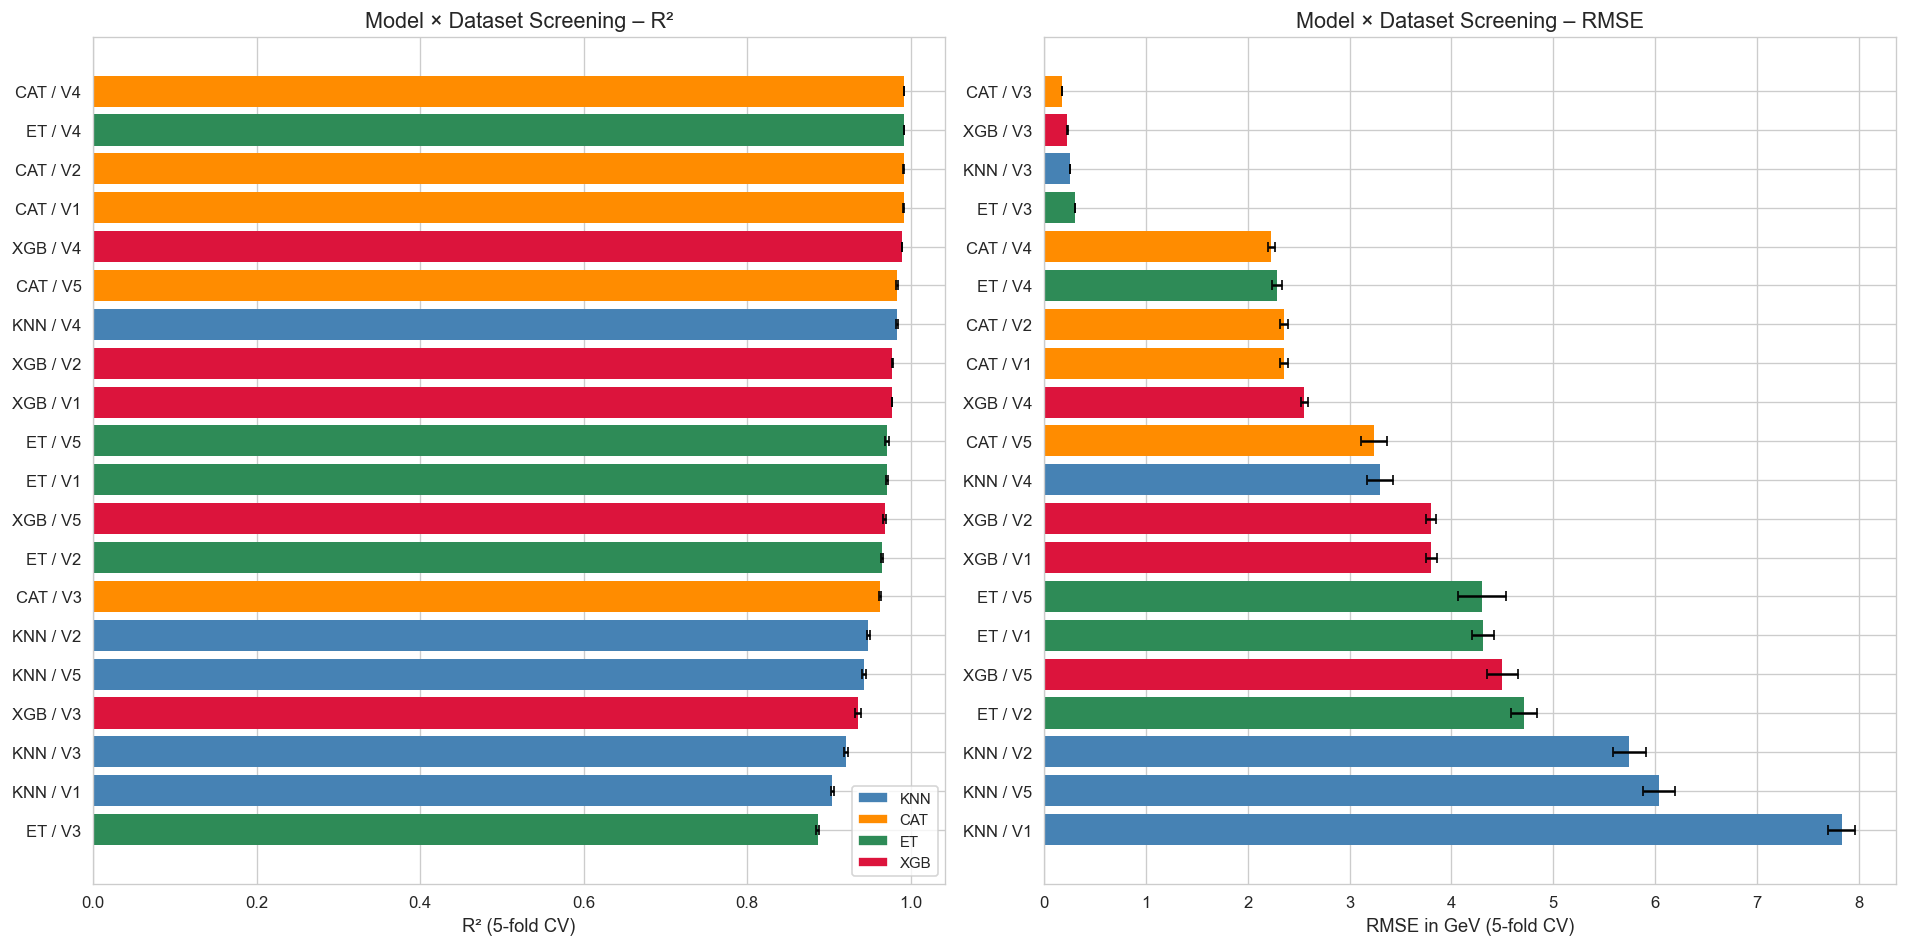

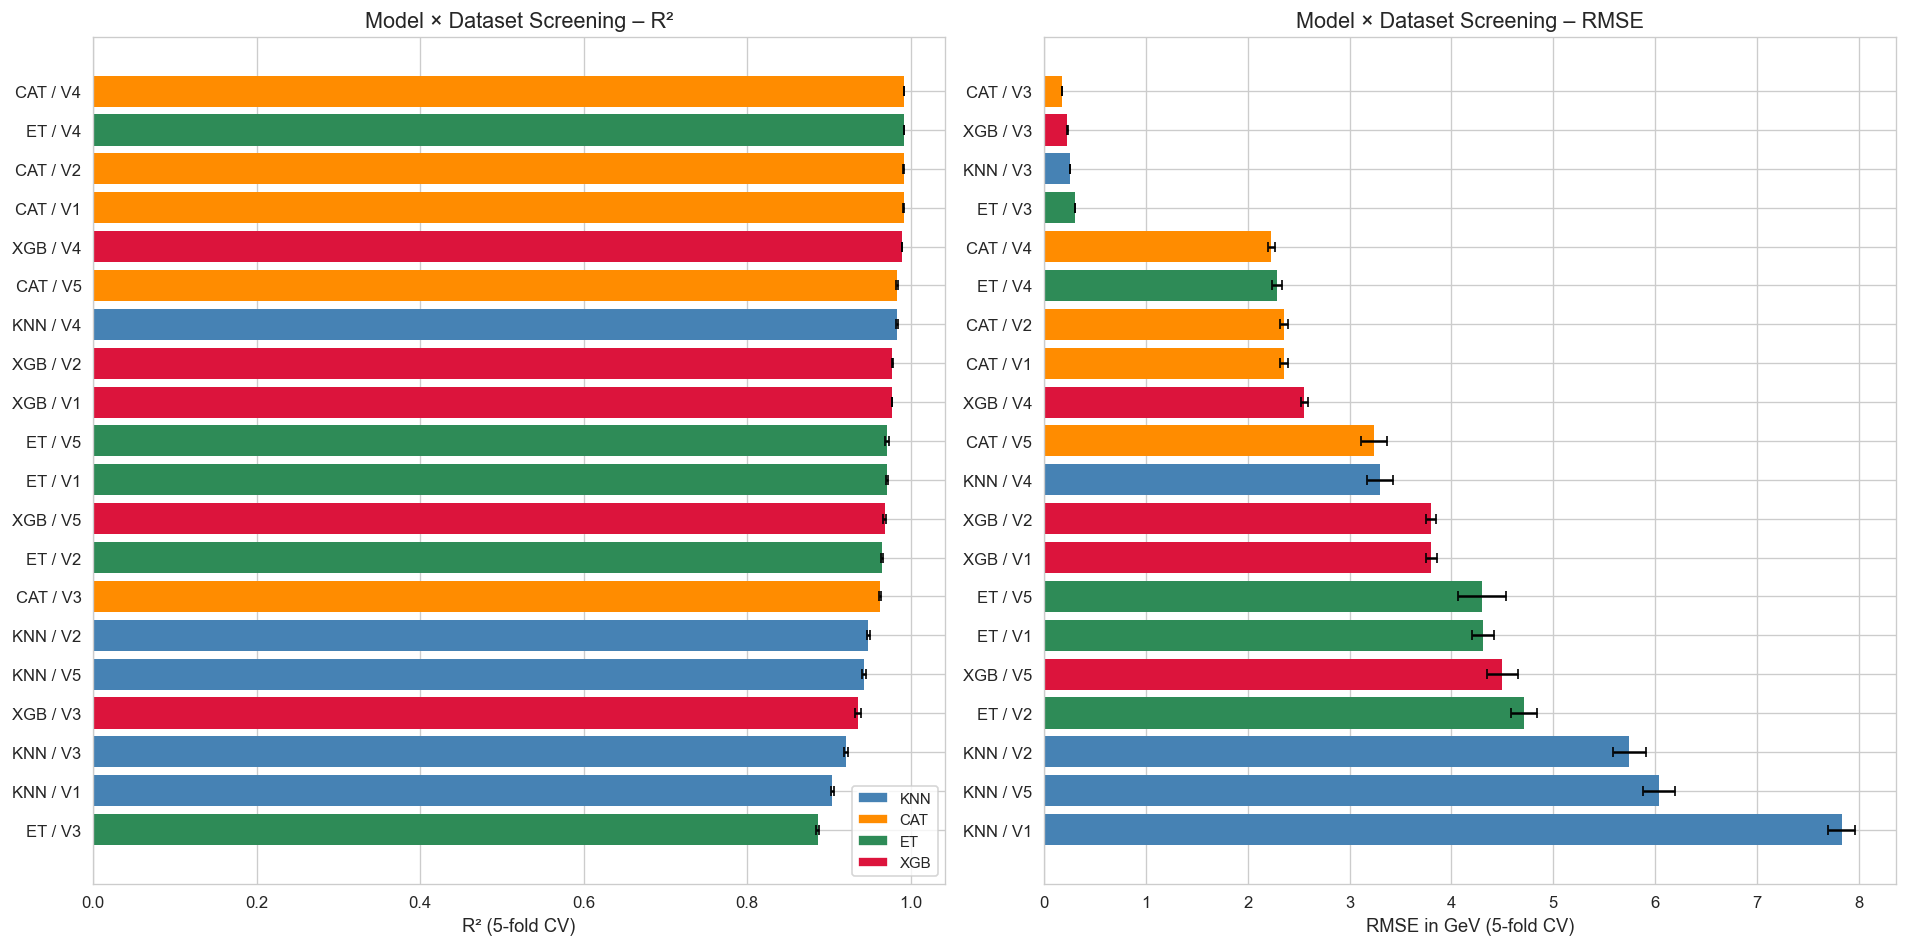

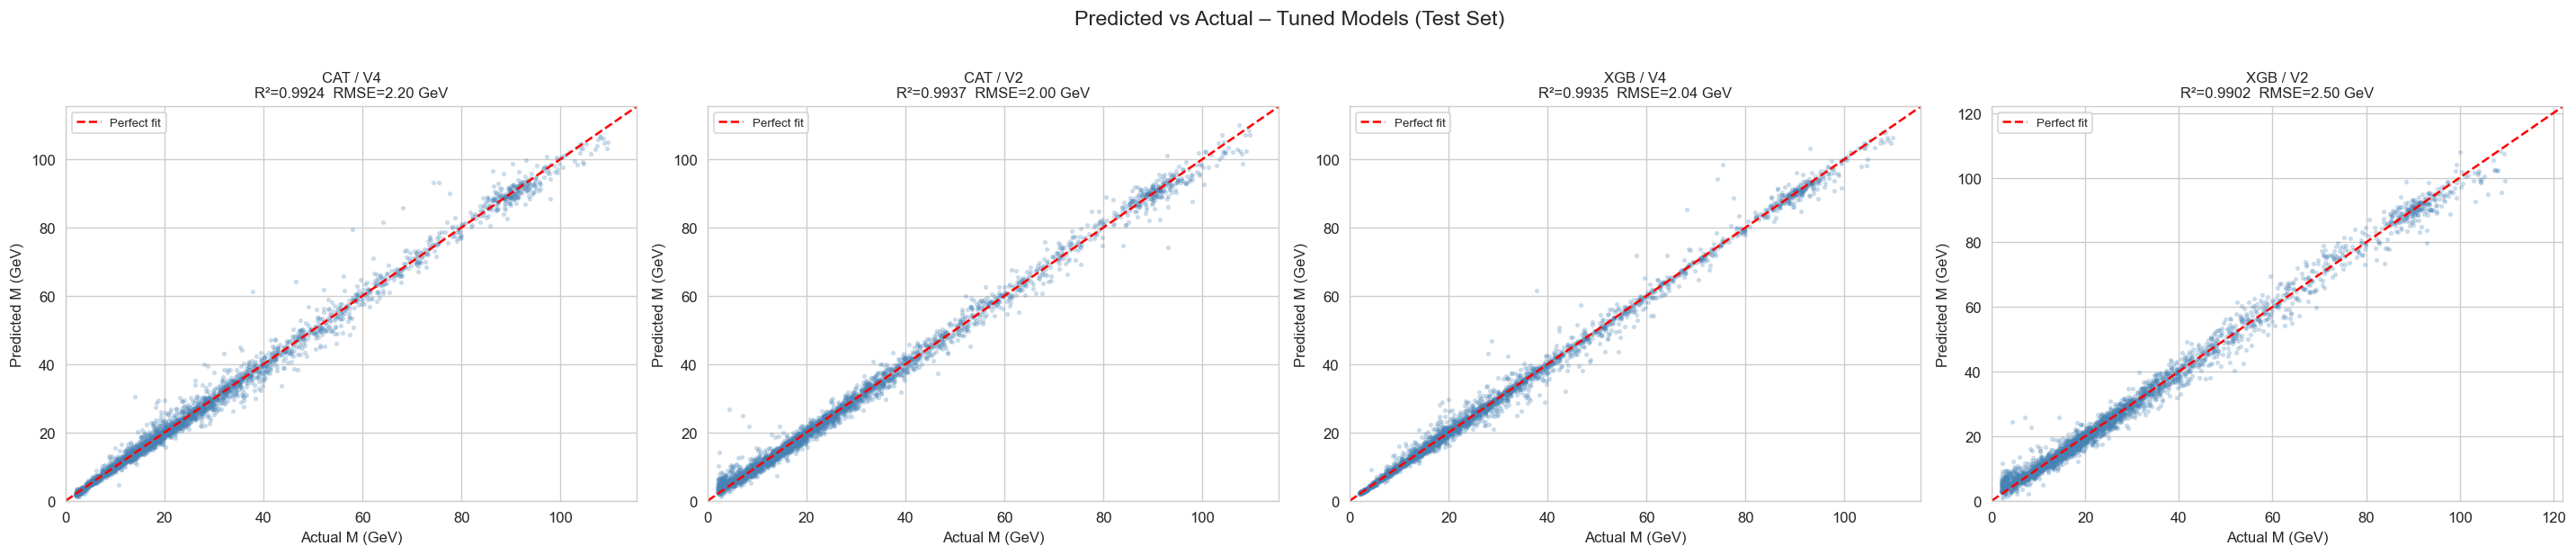

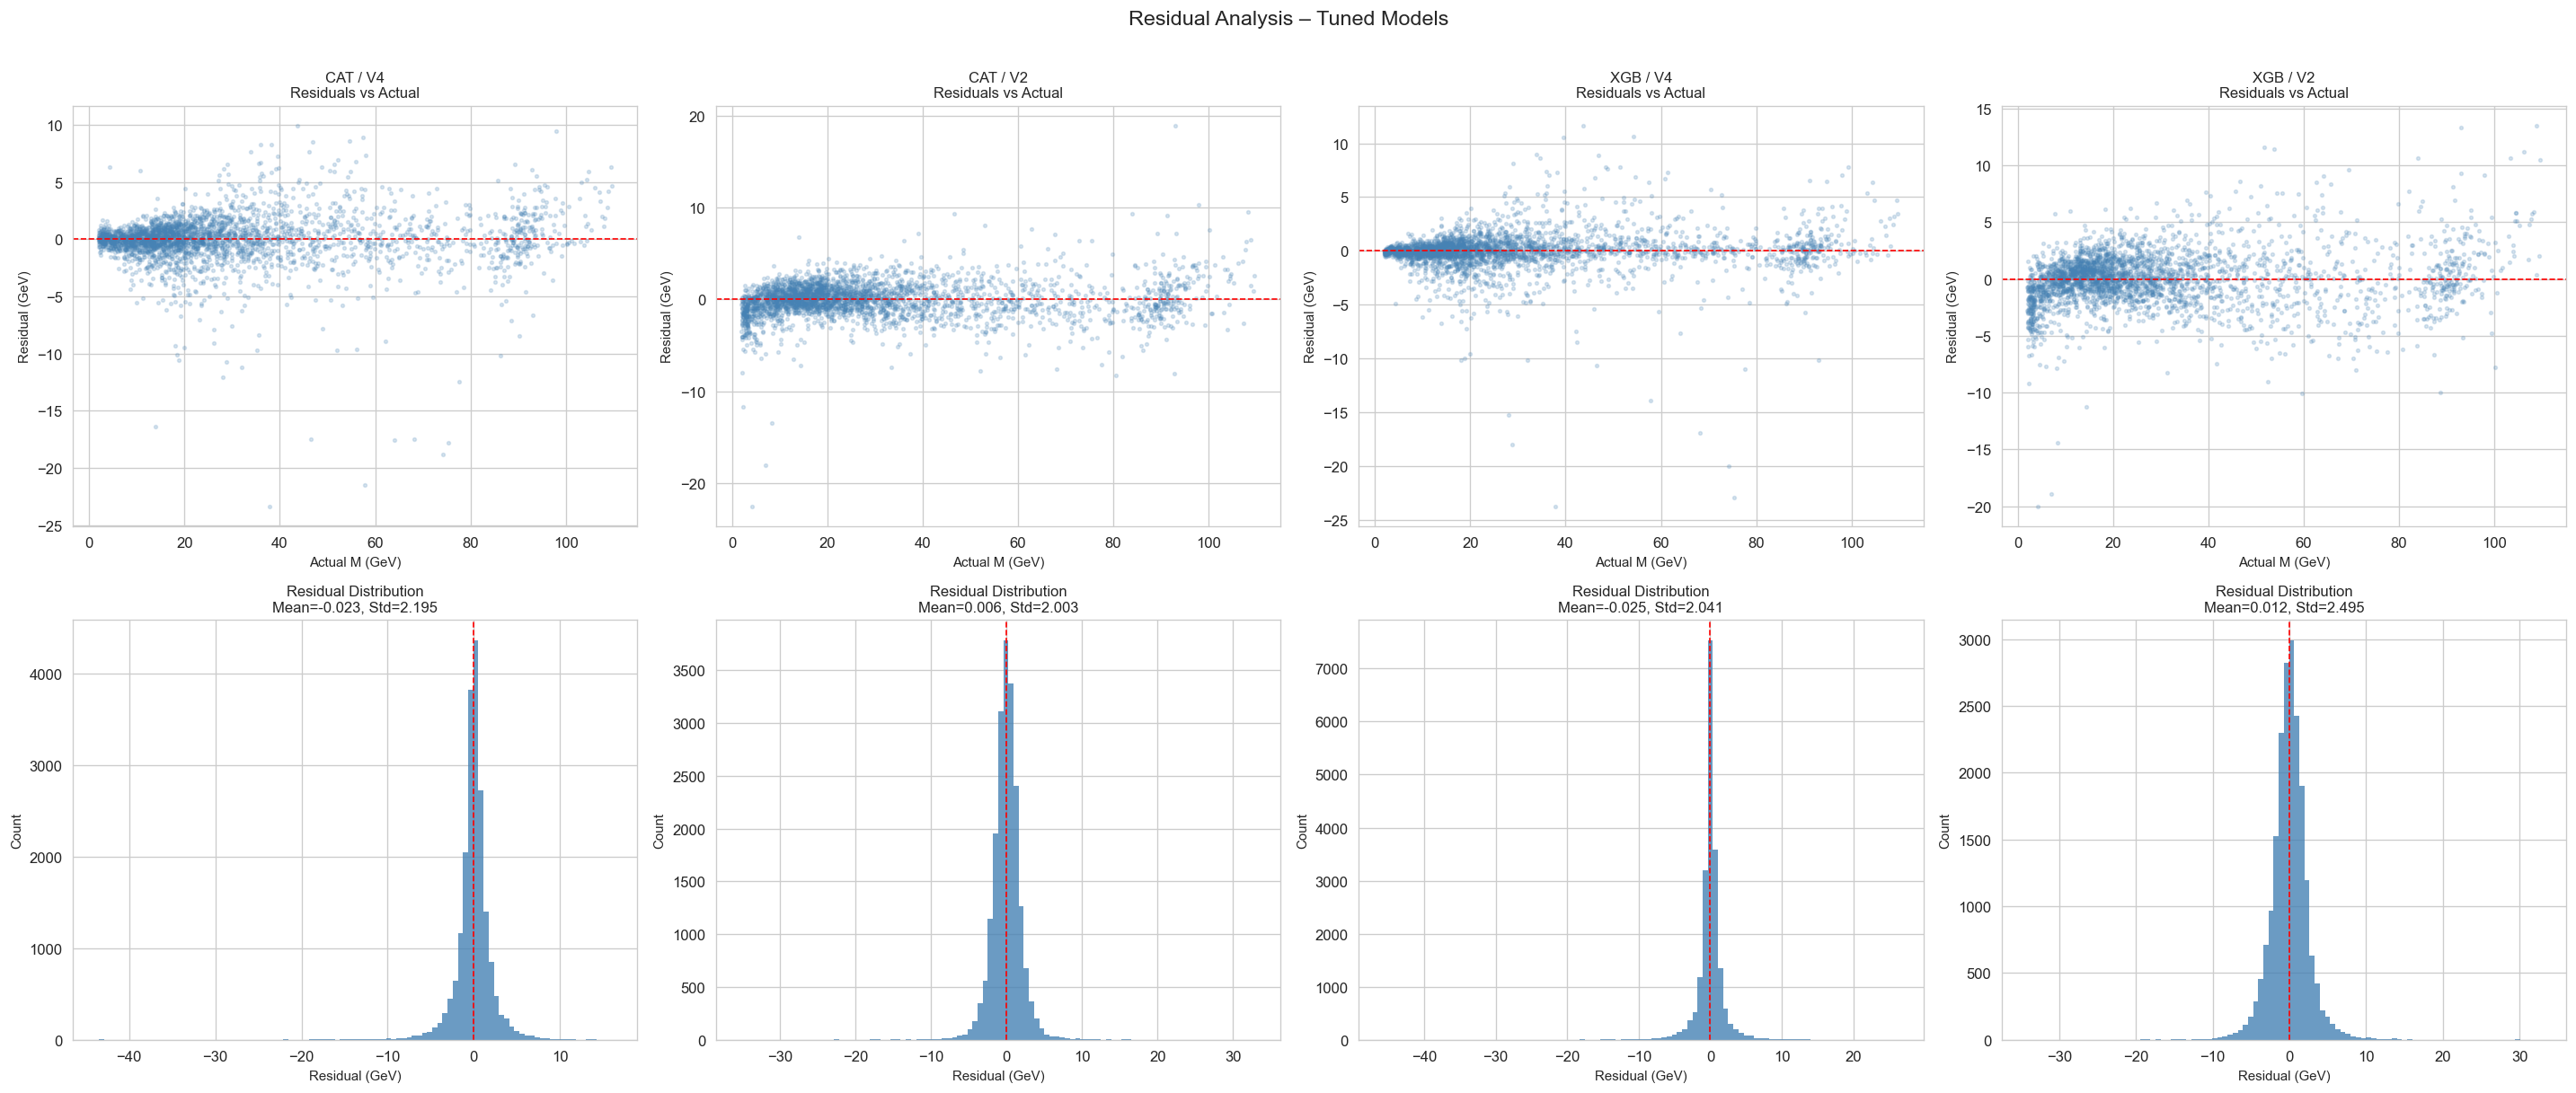

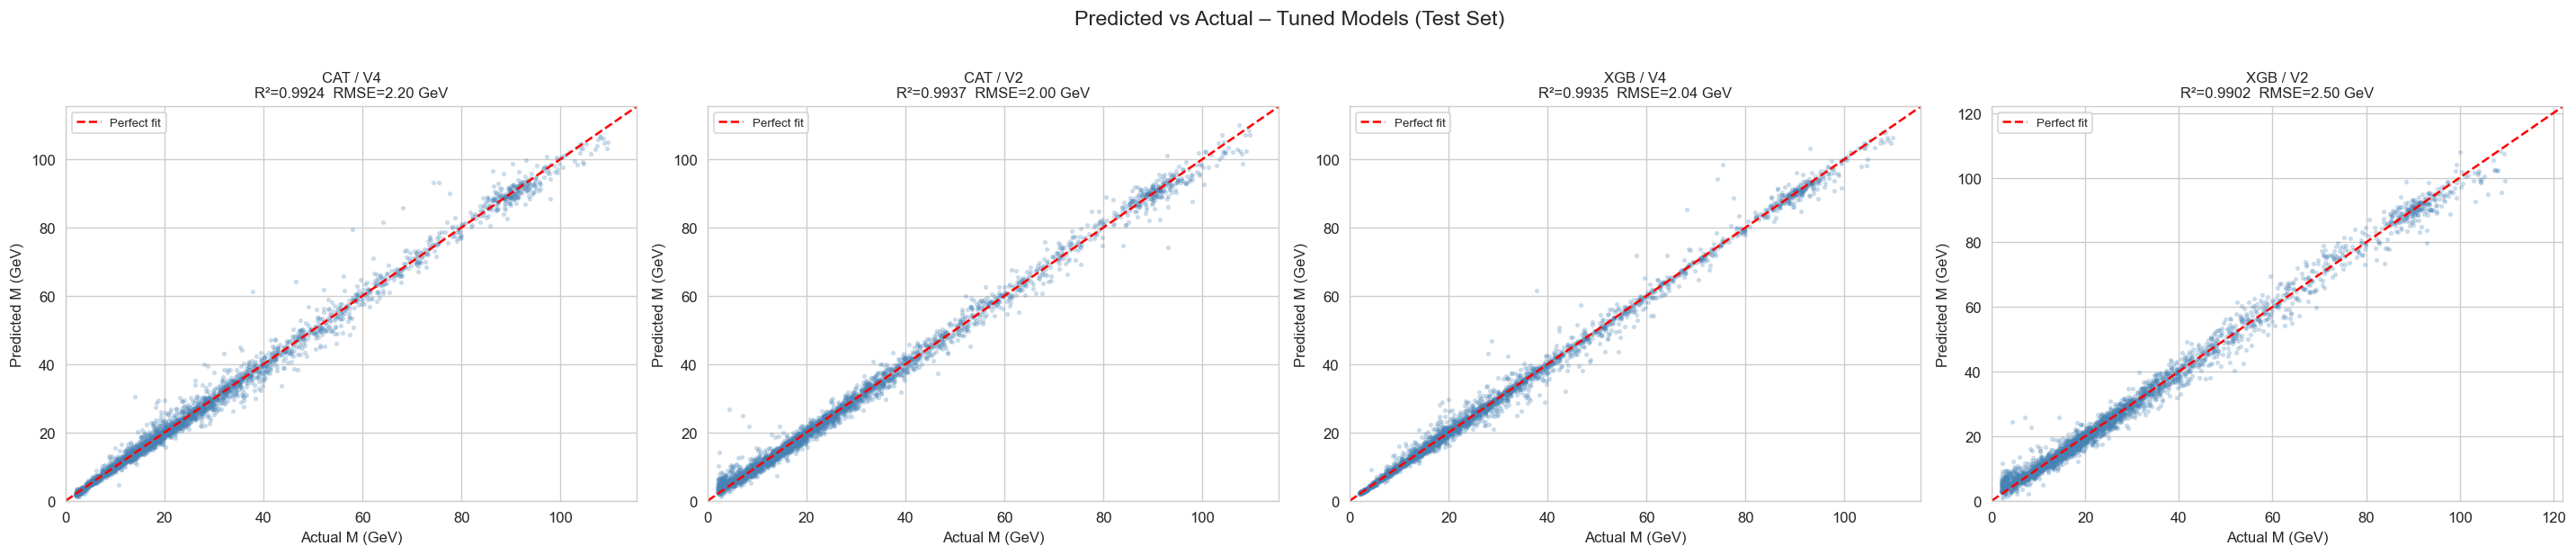

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
n_plots = len(predictions)
n_cols = min(4, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten() if n_plots > 1 else [axes]

for ax, (key, pred) in zip(axes, predictions.items()):
    n = len(pred['y_true'])
    idx = np.random.RandomState(42).choice(n, size=min(3000, n), replace=False)
    ax.scatter(pred['y_true'][idx], pred['y_pred'][idx],
              alpha=0.2, s=5, color='steelblue', rasterized=True)
    lims = [0, max(pred['y_true'].max(), pred['y_pred'].max()) * 1.05]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual M (GeV)', fontsize=10)
    ax.set_ylabel('Predicted M (GeV)', fontsize=10)
    m = compute_metrics(pred['y_true'], pred['y_pred'])
    ax.set_title(f"{pred['model_name']} / {pred['dataset_name']}\n"
                 f"R²={m['R2']:.4f}  RMSE={m['RMSE']:.2f} GeV", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

# Hide unused axes
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Predicted vs Actual – Tuned Models (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig_pred_vs_actual.png', bbox_inches='tight')
plt.show()

### 7.2 Residual Analysis

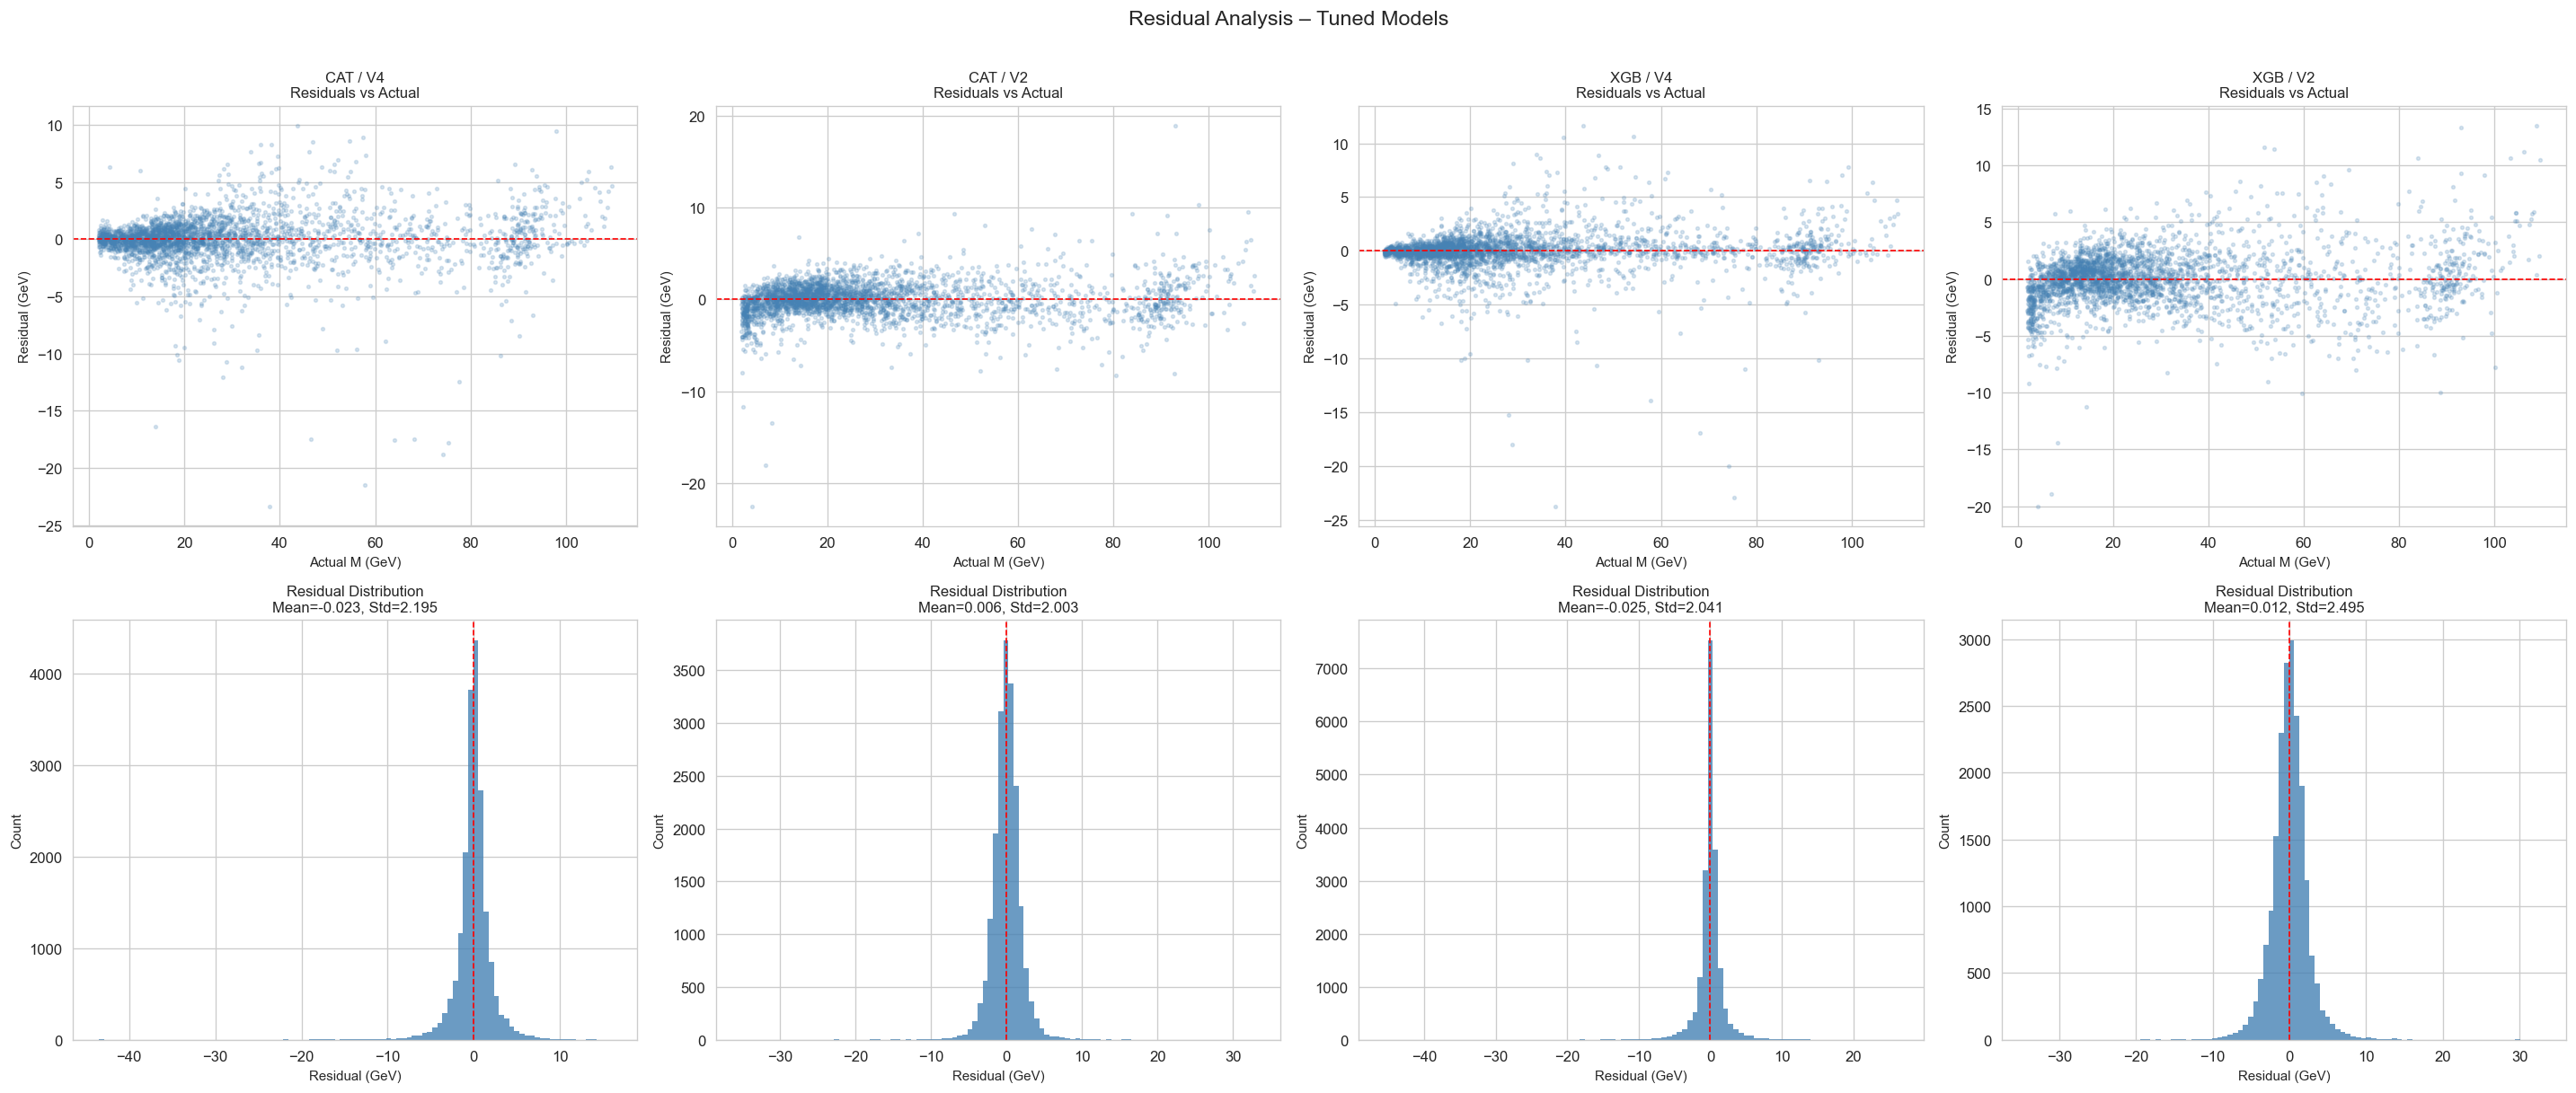

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
n_plots = len(predictions)
n_cols = min(4, n_plots)
n_rows_plot = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(2 * n_rows_plot, n_cols, figsize=(6 * n_cols, 5 * 2 * n_rows_plot))
axes = np.array(axes).reshape(2 * n_rows_plot, n_cols)

for j, (key, pred) in enumerate(predictions.items()):
    col = j % n_cols
    row_base = (j // n_cols) * 2
    residuals = pred['y_true'] - pred['y_pred']
    
    # Residuals vs Actual
    ax = axes[row_base, col]
    idx = np.random.RandomState(42).choice(len(residuals), min(3000, len(residuals)), replace=False)
    ax.scatter(pred['y_true'][idx], residuals[idx], alpha=0.2, s=5, color='steelblue', rasterized=True)
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Actual M (GeV)', fontsize=9)
    ax.set_ylabel('Residual (GeV)', fontsize=9)
    ax.set_title(f"{pred['model_name']} / {pred['dataset_name']}\nResiduals vs Actual", fontsize=10)
    
    # Residual distribution
    ax = axes[row_base + 1, col]
    ax.hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Residual (GeV)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(f'Residual Distribution\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}', fontsize=10)

# Hide unused axes
for row in range(2 * n_rows_plot):
    for col in range(n_cols):
        idx_flat = (row // 2) * n_cols + col
        if idx_flat >= n_plots:
            axes[row, col].set_visible(False)

plt.suptitle('Residual Analysis – Tuned Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'fig_residual_analysis.png', bbox_inches='tight')
plt.show()

### 7.3 Performance by Mass Region

In [45]:
def get_mass_region(m):
    if m < 10:
        return 'Low (< 10 GeV)'
    elif m < 50:
        return 'Mid (10–50 GeV)'
    else:
        return 'High (> 50 GeV)'

region_results = []
for key, pred in predictions.items():
    regions = np.array([get_mass_region(m) for m in pred['y_true']])
    for region in ['Low (< 10 GeV)', 'Mid (10–50 GeV)', 'High (> 50 GeV)']:
        mask = regions == region
        if mask.sum() == 0:
            continue
        m = compute_metrics(pred['y_true'][mask], pred['y_pred'][mask])
        m['Model'] = pred['model_name']
        m['Dataset'] = pred['dataset_name']
        m['Region'] = region
        m['N_events'] = int(mask.sum())
        region_results.append(m)

region_df = pd.DataFrame(region_results)
print('=== Performance by Mass Region ===')
display(region_df[['Model', 'Dataset', 'Region', 'N_events', 'R2', 'RMSE', 'MAE', 'MAPE']]
        .style.format({'R2': '{:.4f}', 'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'MAPE': '{:.2f}'}))

=== Performance by Mass Region ===


,Model,Dataset,Region,N_events,R2,RMSE,MAE,MAPE
0,CAT,V4,Low (< 10 GeV),3697,0.9009,0.791,0.522,9.87
1,CAT,V4,Mid (10–50 GeV),12661,0.9511,2.235,1.361,6.06
2,CAT,V4,High (> 50 GeV),3625,0.9668,2.915,1.910,2.60
3,CAT,V2,Low (< 10 GeV),3697,0.3201,2.072,1.376,32.73
4,CAT,V2,Mid (10–50 GeV),12661,0.9735,1.645,1.160,5.42
5,CAT,V2,High (> 50 GeV),3625,0.9677,2.877,1.968,2.62
6,XGB,V4,Low (< 10 GeV),3697,0.9371,0.630,0.359,6.17
7,XGB,V4,Mid (10–50 GeV),12661,0.9572,2.091,1.146,5.12
8,XGB,V4,High (> 50 GeV),3625,0.9716,2.698,1.505,2.04
9,XGB,V2,Low (< 10 GeV),3697,0.0567,2.441,1.704,41.73


### 7.4 Feature Importance (Best Model)

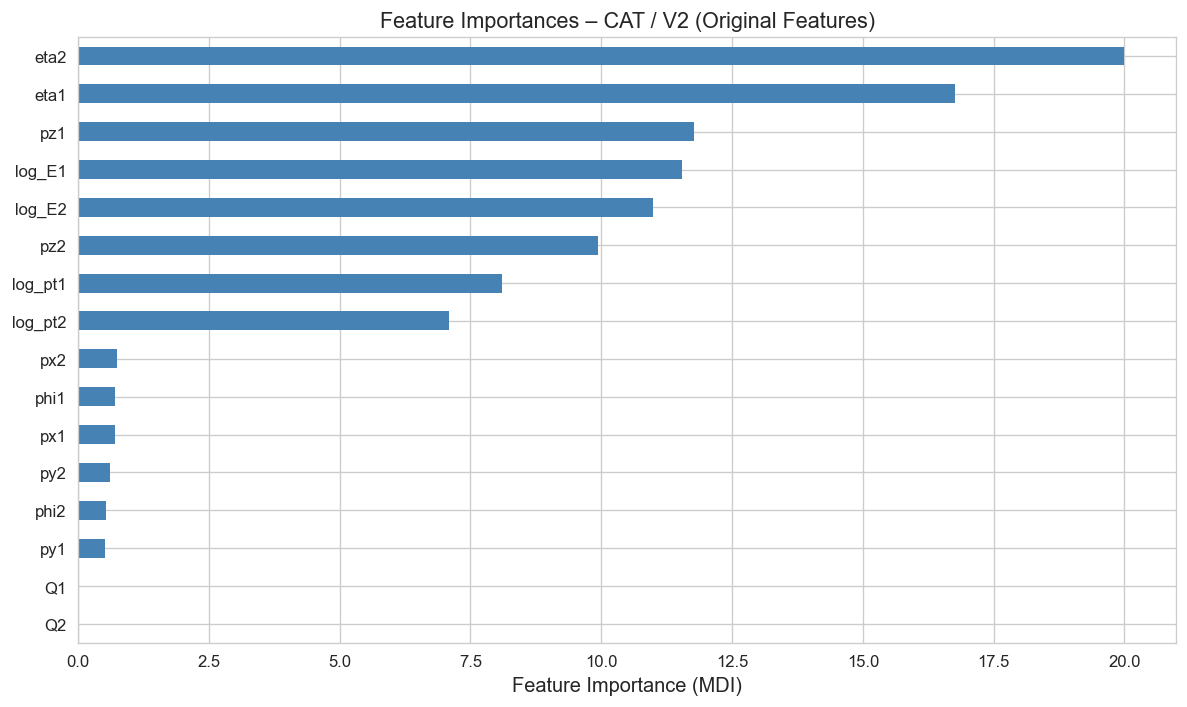

Feature importances:
eta2       19.987782
eta1       16.767489
pz1        11.770458
log_E1     11.550271
log_E2     10.994855
pz2         9.932061
log_pt1     8.106765
log_pt2     7.082522
px2         0.739101
phi1        0.712173
px1         0.698838
py2         0.599879
phi2        0.538960
py1         0.516713
Q1          0.001127
Q2          0.001004


In [46]:
best_key = final_df.loc[final_df['R2'].idxmax()]
best_combo_key = f"{best_key['Model']}_{best_key['Dataset']}"
best_gs = grid_results[best_combo_key]['grid_search']
best_estimator = best_gs.best_estimator_

if hasattr(best_estimator, 'named_steps'):
    actual_model = best_estimator.named_steps['model']
else:
    actual_model = best_estimator

best_dataset = best_key['Dataset']
uses_pca = datasets_raw[best_dataset]['pca']

if hasattr(actual_model, 'feature_importances_'):
    importances = actual_model.feature_importances_
    if uses_pca:
        feat_names = [f'PC{i+1}' for i in range(len(importances))]
        title_suffix = '(PCA Components)'
    else:
        feat_names = datasets_raw[best_dataset]['feature_names']
        title_suffix = '(Original Features)'
    
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (MDI)', fontsize=12)
    ax.set_title(f'Feature Importances – {best_key["Model"]} / {best_dataset} {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'fig_feature_importance_best.png', bbox_inches='tight')
    plt.show()
    
    print('Feature importances:')
    print(feat_imp.to_string())
else:
    print(f'Feature importances not available for {type(actual_model).__name__}')

---
## 8. Comparison of Default vs Tuned Performance

In [47]:
comparison_rows = []
for key, res in grid_results.items():
    model_name = res['model_name']
    dataset_name = res['dataset_name']
    default_r2 = cv_df[
        (cv_df['Model'] == model_name) & (cv_df['Dataset'] == dataset_name)
    ]['R2_mean'].values[0]
    tuned_r2 = res['best_cv_r2']
    comparison_rows.append({
        'Model': model_name,
        'Dataset': dataset_name,
        'Default R² (CV)': default_r2,
        'Tuned R² (CV)': tuned_r2,
        'Improvement': tuned_r2 - default_r2
    })

comp_df = pd.DataFrame(comparison_rows)
print('=== Default vs Tuned Performance ===')
display(comp_df.style.format({
    'Default R² (CV)': '{:.4f}',
    'Tuned R² (CV)': '{:.4f}',
    'Improvement': '{:+.4f}'
}))

=== Default vs Tuned Performance ===


,Model,Dataset,Default R² (CV),Tuned R² (CV),Improvement
0,CAT,V4,0.9922,0.9929,+0.0007
1,CAT,V2,0.9913,0.9930,+0.0016
2,XGB,V4,0.9898,0.9934,+0.0036
3,XGB,V2,0.9773,0.9897,+0.0123


### 8.1 Train vs Test R² (Overfitting Check)

In [49]:
overfit_rows = []
for key, res in grid_results.items():
    gs = res['grid_search']
    best_idx = gs.best_index_
    train_r2 = gs.cv_results_['mean_train_score'][best_idx]
    test_r2 = gs.cv_results_['mean_test_score'][best_idx]
    overfit_rows.append({
        'Model': res['model_name'],
        'Dataset': res['dataset_name'],
        'Train R² (CV)': train_r2,
        'Val R² (CV)': test_r2,
        'Gap (Train - Val)': train_r2 - test_r2
    })

overfit_df = pd.DataFrame(overfit_rows)
print('=== Overfitting Check: Train vs Validation R² ===')
print('(A small gap means no significant overfitting)\n')
display(overfit_df.style.format({
    'Train R² (CV)': '{:.4f}',
    'Val R² (CV)': '{:.4f}',
    'Gap (Train - Val)': '{:.4f}'
}).map(lambda x: 'background-color: #ffcccc' if isinstance(x, float) and x > 0.02 else '',
            subset=['Gap (Train - Val)']))

=== Overfitting Check: Train vs Validation R² ===
(A small gap means no significant overfitting)



,Model,Dataset,Train R² (CV),Val R² (CV),Gap (Train - Val)
0,CAT,V4,0.9947,0.9929,0.0019
1,CAT,V2,0.9955,0.9930,0.0025
2,XGB,V4,0.9994,0.9934,0.0060
3,XGB,V2,0.9953,0.9897,0.0057


---
## 9. Discussion

### 9.1 Key Findings

- **Best tuned performance on the test set:** The highest test-set `R^2` was achieved by **CatBoost on V2** (`R^2 = 0.9937`, `RMSE = 2.003 GeV`, `MAE = 1.347 GeV`, `MAPE = 9.96%`).
- **Best error profile overall:** **XGBoost on V4** gave the best balance of absolute and relative error (`R^2 = 0.9935`, `RMSE = 2.041 GeV`, `MAE = 1.065 GeV`, `MAPE = 4.76%`), making it the most practically attractive model-dataset combination despite CatBoost/V2 having a slightly higher `R^2`.
- **Feature selection was more useful than PCA:** The reduced, domain-driven **V4** dataset consistently performed best during screening and final tuning. In contrast, **V5 (PCA)** underperformed relative to both V2 and V4, indicating that preserving physically meaningful engineered variables was more beneficial than variance-based compression.
- **Model ranking after screening:** CatBoost and XGBoost were clearly the strongest models, which is why they were selected for GridSearchCV. KNN was competitive on V4 but weaker overall, while ExtraTrees performed well but did not exceed the tuned CatBoost/XGBoost combinations.
- **Tuning improved results, but only modestly for the strongest models:** Grid search improved CatBoost by `+0.0007` on V4 and `+0.0016` on V2, while XGBoost improved by `+0.0036` on V4 and `+0.0123` on V2. This suggests that the default configurations were already strong and that preprocessing choice mattered at least as much as hyperparameter tuning.
- **Overfitting remained limited:** The train-validation `R^2` gaps were small for all tuned runs (`0.0019` to `0.0060`), indicating that the selected models generalize well and that the tuned configurations did not overfit severely.

### 9.2 Comparison with Literature

| Aspect | Kuzu (2023) | Our Study |
|--------|-------------|-----------|
| Dataset | CERN dielectron data, focused on the Z-boson peak region | CERN dielectron data, full invariant-mass regression setting |
| Task | Classification of Z-boson spectrum in the `60-120 GeV/c^2` region | Regression of invariant mass `M` across the full available range |
| Algorithms | RF, WRF, BRF, LightGBM, DNN | KNN, ExtraTrees, CatBoost, XGBoost |
| Best reported method | LightGBM for dielectron classification | CatBoost/V2 by `R^2`; XGBoost/V4 by MAE and MAPE |
| Features used | Not directly comparable from the article abstract | 8 selected physics-informed features in V4, plus V2/V5 variants |
| Dimensionality reduction | Not emphasized in the cited study | Feature selection and PCA were both tested |
| Best reported metric | `99.311%` accuracy, `96.326%` sensitivity, `93.500%` precision (dielectron) | Best `R^2 = 0.9937`, `RMSE = 2.003 GeV`, `MAE = 1.065-1.347 GeV` depending on model/dataset |
| Comparability | Limited: classification metrics on a restricted peak region | Limited: regression metrics on the full mass spectrum |

The literature comparison should therefore be interpreted cautiously. The cited study solves a **different prediction problem** using **classification metrics**, whereas this notebook solves a **continuous regression** problem over a broader physical range. The main common conclusion is that ensemble tree-based methods are highly effective for this dataset family.

### 9.3 Domain-Specific Validation

The results are physically plausible and internally consistent with the underlying kinematics of dielectron events. The best models rely primarily on kinematic variables such as `eta1`, `eta2`, `pz1`, `pz2`, `log_E1`, and `log_E2`, while charge variables (`Q1`, `Q2`) have negligible importance. This is consistent with the invariant-mass relationship, which depends mainly on the energies and momenta of the two leptons rather than on charge alone.

Performance by mass region also supports the validity of the models. For the stronger V4 representation, both tuned models remained accurate across all three regions, with **XGBoost/V4** reaching `R^2 = 0.9371` in the low-mass region, `0.9572` in the mid region, and `0.9716` in the high-mass region. **CatBoost/V4** showed a similar pattern (`0.9009`, `0.9511`, `0.9668`). In contrast, the V2 versions were much weaker in the low-mass region (`R^2 = 0.3201` for CatBoost and `0.0567` for XGBoost), showing that the domain-driven V4 feature set captures the low-mass structure far better than the generic transformed V2 representation.

Overall, the results suggest that domain-informed feature engineering is not merely a convenience but a meaningful improvement for reconstructing invariant mass accurately across different resonance regions.

### 9.4 Study Limitations

- Hyperparameter tuning remained computationally expensive even after narrowing the search to the top two models and using GPU support where possible.
- The evaluation uses a single `80/20` holdout split for final testing, so results may vary slightly under repeated resampling.
- The literature comparison is only partially comparable because the cited study uses classification on the Z-peak region, while this work uses regression on the full spectrum.
- PCA was not competitive here, but that conclusion is specific to the current preprocessing design and parameter choices.
- The strong performance of V4 partly reflects the fact that its engineered features encode well-known physical structure, so some of the predictive advantage comes from explicit domain knowledge rather than purely model capacity.
- Low-mass events remain the hardest regime for the less specialized dataset versions, especially V2, indicating that preprocessing choice has a large effect on robustness across the full mass range.


---
## 10. Final Summary

In [50]:
print('=' * 75)
print('DELIVERABLE 3 – FINAL SUMMARY')
print('=' * 75)
print()
print('Dataset: CERN Electron Collision – 100,000 dielectron events')
print('Task:    Regression – predict invariant mass M (GeV)')
print()
print(f'Models evaluated (screening): KNN, CatBoost, ExtraTrees, XGBoost')
print(f'Dataset versions:  V1 (baseline, 16 feat), V2 (log, 16 feat), '
      f'V3 (log target, 16 feat),\n'
      f'                   V4 (selected, 8 feat), V5 (PCA/SVD, ~10 comp)')
print(f'\nModels tuned:      {SELECTED_MODELS}')
print(f'Datasets tuned on: {SELECTED_DATASETS}')
print()
print('--- Best Model (Test Set) ---')
best_row = final_df.loc[final_df['R2'].idxmax()]
print(f'Model:     {best_row["Model"]}')
print(f'Dataset:   {best_row["Dataset"]}')
print(f'R²:        {best_row["R2"]:.4f}')
print(f'RMSE:      {best_row["RMSE"]:.3f} GeV')
print(f'MAE:       {best_row["MAE"]:.3f} GeV')
print(f'MAPE:      {best_row["MAPE"]:.2f}%')
print(f'Params:    {best_row["Best Params"]}')
print()
print('=' * 75)

DELIVERABLE 3 – FINAL SUMMARY

Dataset: CERN Electron Collision – 100,000 dielectron events
Task:    Regression – predict invariant mass M (GeV)

Models evaluated (screening): KNN, CatBoost, ExtraTrees, XGBoost
Dataset versions:  V1 (baseline, 16 feat), V2 (log, 16 feat), V3 (log target, 16 feat),
                   V4 (selected, 8 feat), V5 (PCA/SVD, ~10 comp)

Models tuned:      ['CAT', 'XGB']
Datasets tuned on: ['V4', 'V2']

--- Best Model (Test Set) ---
Model:     CAT
Dataset:   V2
R²:        0.9937
RMSE:      2.003 GeV
MAE:       1.347 GeV
MAPE:      9.96%
Params:    {'model__depth': 8, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1, 'model__n_estimators': 500}



---
## References

[1] McCauley, T. (2014). Events with two electrons from 2010. CERN Open Data Portal. DOI: 10.7483/OPENDATA.CMS.PCSW.AHVG  
[2] Kilic, H., Ozturk, S., & Yildirim, E. (2023). Machine learning model performances for the Z boson mass identification through dielectron decay channel. *The European Physical Journal Plus*, 138(1), 87.  
[3] Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.  
[4] Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.  
[5] Breiman, L. (2001). ExtraTreess. *Machine Learning*, 45(1), 5-32.  
[6] Vapnik, V. (1995). *The Nature of Statistical Learning Theory*. Springer.  
[7] Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Trans. Information Theory*, 13(1), 21-27.  
[8] Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer. DOI: 10.1007/b98835